In [1]:
import sys
sys.path.append('../src/')
from xpcs import *
from sims import *
from autocorrelations import *
import cv2
from scipy.special import erfinv
import pyopencl as cl
from pathlib import Path
import matplotlib.cm as cm
import json
import matplotlib.ticker as ticker
from cmcrameri import cm
import matplotlib as mpl


%matplotlib notebook

In [2]:
CONFIG_FILE_NAME = "NPS_11092023_processed_config.json"

figure_path = '/Users/eriklamb/Documents/Publications/NPS_Petra/Figures/'


# Define the path to the configuration file
config_path = Path("/Users/eriklamb/Documents/Python/Projects/XPCS/configs/"+CONFIG_FILE_NAME)

# Open and load the JSON configuration file
with open(config_path, "r") as file:
    config = json.load(file)
    #json_str = json.loads(jsonString, strict=False)

In [357]:
T = 405

BASE = Path(config.get("BASE"))
file_processed = BASE/Path(config.get(f"{T}_processed"))
file_results = BASE/Path(config.get(f"{T}_results"))

with h5py.File(file_processed, 'r') as DATA:
    det          = DATA['data/det'][:]
    frameSpacing = DATA['experimental_parameters/frame_spacing'][:][0]
    
with h5py.File(file_results, 'r') as DATA:
    masks        = DATA['XPCS/Mask'][:]
    dQ           = DATA['XPCS/dQ'][:]
    g2s          = DATA['XPCS/G2_Results'][:]
    g2s_err      = DATA['XPCS/G2_error'][:]
    delays       = DATA['XPCS/delays'][:]

In [351]:
masks.shape

(10, 1300, 750)

# Check Mask

<IPython.core.display.Javascript object>


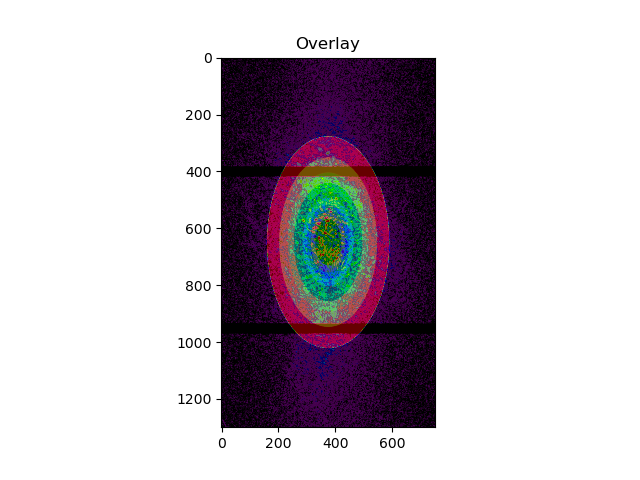

Text(0.5, 1.0, 'Overlay')

In [352]:
fig,ax = plt.subplots()

masks_plot = np.zeros(masks.shape)

for i in range(masks_plot.shape[0]):
    masks_plot[i,:,:] = (i+1)*masks[i,:,:]

#Sum of the masks for a single mask image
mask_sum = np.sum(masks_plot,axis=0)

ax.imshow(mask_sum-1, cmap='nipy_spectral',clim =(1,mask_sum.max()), alpha=1)
# Overlay the second image with a 'plasma' color scale and some transparency
ax.imshow(np.sum(det[0:5,:,:],axis=0)+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=35),alpha=0.55)
ax.set_title('Overlay')

<IPython.core.display.Javascript object>


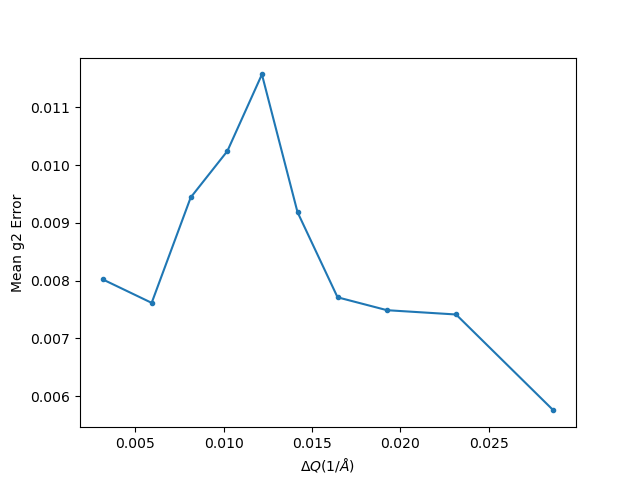

Text(0.5, 0, '$\\Delta Q (1/Å)$')

In [353]:
fig,ax = plt.subplots()

ax.plot(dQ,np.mean(g2s_err,axis=1),'.-')
ax.set_ylabel('Mean g2 Error')
ax.set_xlabel('$\\Delta Q (1/Å)$')

<IPython.core.display.Javascript object>


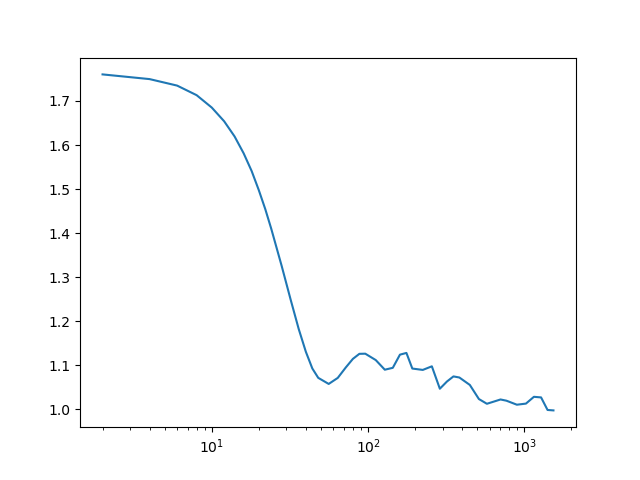

In [354]:
fig,ax = plt.subplots()

ax.semilogx(delays[0],g2s[0,:])

<IPython.core.display.Javascript object>


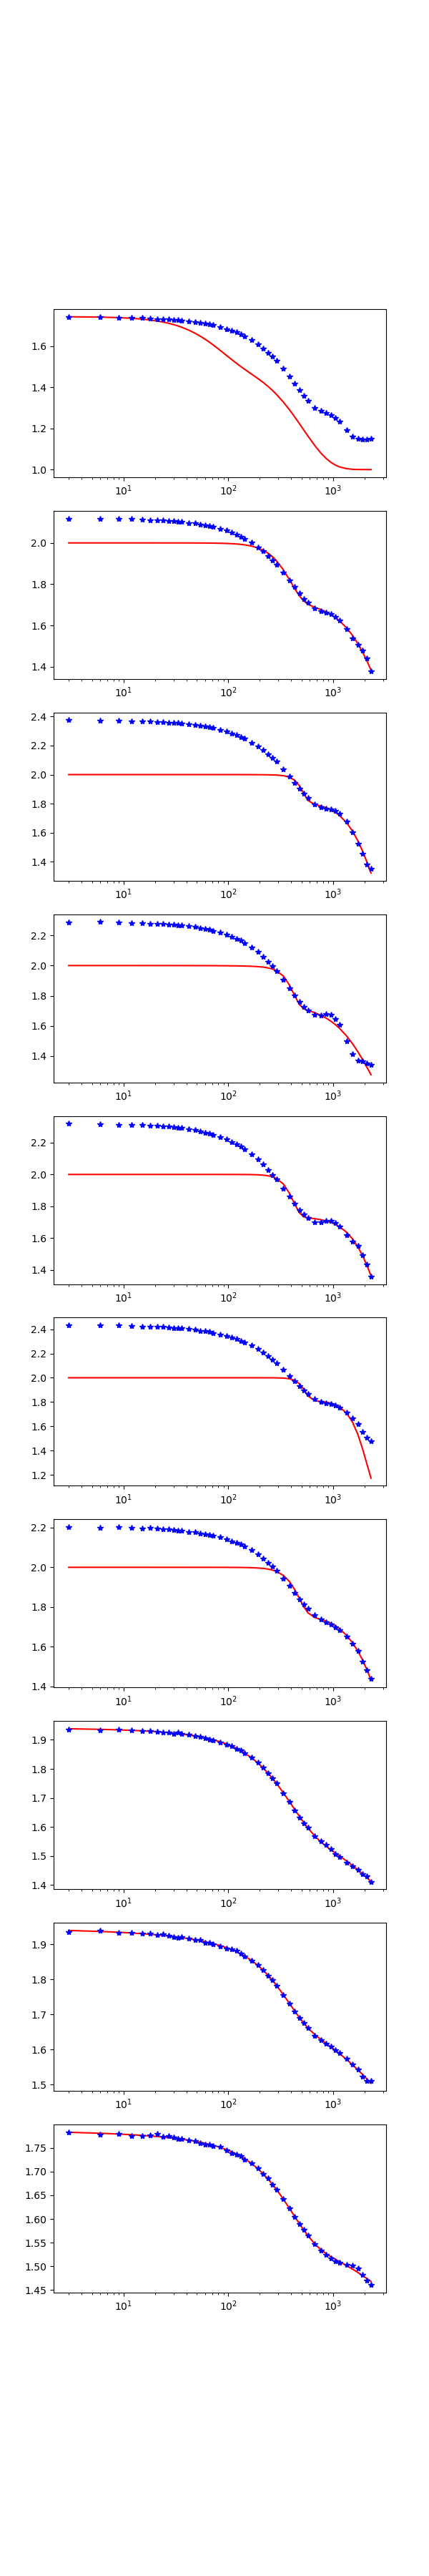

In [358]:
Single = False
Poly = True

fig,ax = plt.subplots(g2s.shape[0],1,figsize=(6,36))

if Single:
    #Single Exponential
    POPT = np.zeros((g2s.shape[0],3))
    PCOV = np.zeros((g2s.shape[0],3))
if not Single:
    #Double Exponential
    POPT = np.zeros((g2s.shape[0],6))
    PCOV = np.zeros((g2s.shape[0],6))
if Poly:
    tau_f = np.zeros((g2s.shape[0],1))
    beta_f = np.zeros((g2s.shape[0],1))

for i,(g2,g2err) in enumerate(zip(g2s,g2s_err)): 
    if Single:
        trunc = -delays.shape[1]
        
        lower_bounds = [0,0,0]
        upper_bounds = [np.inf,np.inf,np.inf]
        
        popt,pcov = curve_fit(g2_exp,delays[0,:-trunc],g2[:-trunc],sigma=g2err[:-trunc],absolute_sigma=True,p0=[0.6,200,1.5],bounds=(lower_bounds, upper_bounds)) #,p0=[1,0.5,50,500,2,1])
        ax[i].semilogx(delays[0],g2_exp(delays[0],*popt),'r')
        
        #tau_f[i,0]  = popt[1]
        #beta_f[i,0] = popt[2]
    if not Single:
        #lower_bounds = [-np.inf,-np.inf,-np.inf,-np.inf,-np.inf,-np.inf]  # c >= 0
        lower_bounds = [0,0,0,0,0,0]
        upper_bounds = [1,1,np.inf,np.inf,np.inf,np.inf]
        
        if i==0:
            trunc = -2#-delays.shape[1]
            popt,pcov = curve_fit(g2_two_tau,delays[0,:-trunc],g2[:-trunc],sigma=g2err[:-trunc],absolute_sigma=True,p0=[1.0,0.15,100,2000,1.0,1.0],bounds=(lower_bounds, upper_bounds))#,p0=[POPT[i-1,0],POPT[i-1,1],POPT[i-1,2],POPT[i-1,3]])

        elif i>0:
            
            if i == 5:
                trunc = 5
            if i != 5:    
                trunc = -delays.shape[1]
                
            #trunc = 4
            popt,pcov = curve_fit(g2_two_tau,delays[0,:-trunc],g2[:-trunc],sigma=g2err[:-trunc],absolute_sigma=True,p0=[POPT[i-1,0],POPT[i-1,1],POPT[i-1,2],POPT[i-1,3],POPT[i-1,4],POPT[i-1,5]],bounds=(lower_bounds, upper_bounds))#,p0=[POPT[i-1,0],POPT[i-1,1],POPT[i-1,2],POPT[i-1,3]])


        
        
        
        
        #popt,pcov = curve_fit(g2_two_tau,delays[0,:-trunc],g2[:-trunc],sigma=g2err[:-trunc],absolute_sigma=True,p0=[1,0.7,30,300,2.0,0.9],bounds=(lower_bounds, upper_bounds))#,p0=[POPT[i-1,0],POPT[i-1,1],POPT[i-1,2],POPT[i-1,3]])
        ax[i].semilogx(delays[0],g2_two_tau(delays[0],*popt),'r')
        #tau_f[i,0]  = popt[2]
        #beta_f[i,0] = popt[4]
    
    tau = popt[2]
    #for d in np.array([1,3,9,27]):

        #ax[i].axvline(x=tau*d, color='k', linestyle='--', linewidth=1)
    
    POPT[i,:]+=popt
    PCOV[i,:]+=np.sqrt(np.diag(pcov))
    
    ax[i].semilogx(delays[0],g2,'b*')
    #ax[i].errorbar(delays[0],g2,yerr=g2err,fmt='none',ecolor='b',capsize=2)

    

<IPython.core.display.Javascript object>


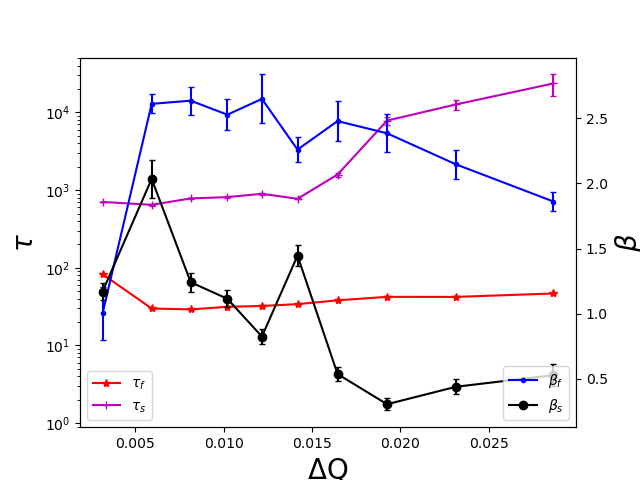

In [356]:
fig,ax = plt.subplots()

# Second y-axis for the second dataset
ax2 = ax.twinx()

if Single:
    ax.semilogy(dQ,POPT[:,1],'r*-',label='$\\tau_f$')
    ax.errorbar(dQ,POPT[:,1], yerr=PCOV[:,1],fmt='none',ecolor='r',capsize=2)

    ax2.plot(dQ,POPT[:,2],'b.-',label='$\\beta_f$')
    ax2.errorbar(dQ,POPT[:,2], yerr=PCOV[:,2],fmt='none',ecolor='b',capsize=2)
if Poly:
    ax.semilogy(dQ,POPT[:,2],'r*-',label='$\\tau_f$')
    ax.errorbar(dQ,POPT[:,2], yerr=PCOV[:,2],fmt='none',ecolor='r',capsize=2)

    ax2.plot(dQ,POPT[:,4],'b.-',label='$\\beta_f$')
    ax2.errorbar(dQ,POPT[:,4], yerr=PCOV[:,4],fmt='none',ecolor='b',capsize=2)

    ax.semilogy(dQ,POPT[:,3],'m+-',label='$\\tau_s$')
    ax.errorbar(dQ,POPT[:,3], yerr=PCOV[:,3],fmt='none',ecolor='m',capsize=2)

    ax2.plot(dQ,POPT[:,5],'ko-',label='$\\beta_s$')
    ax2.errorbar(dQ,POPT[:,5], yerr=PCOV[:,5],fmt='none',ecolor='k',capsize=2)

#ax.plot(dQ,tau_f,'r*-')
#ax2.plot(dQ,beta_f,'b.-')

ax.set_ylabel('$\\tau$',fontsize=20)
ax2.set_ylabel('$\\beta$',fontsize=20)

ax.set_xlabel('$\\Delta$Q',fontsize=20)
ax.legend(loc='lower left')
ax2.legend(loc='lower right')

<IPython.core.display.Javascript object>


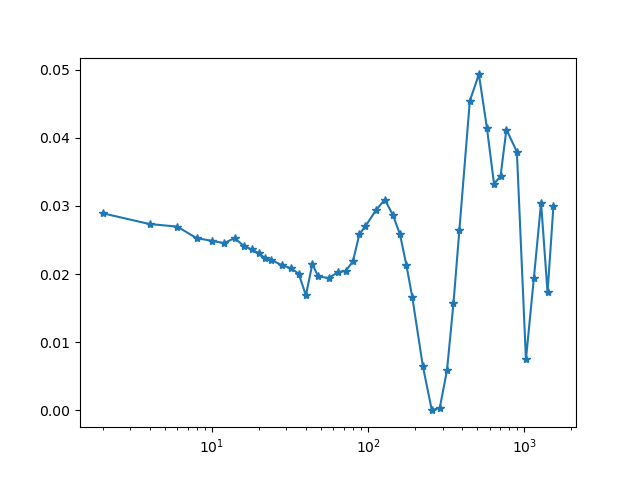

/var/folders/wg/d6rgw7nd3p9gs4wz8ngmmpj00000gn/T/ipykernel_88733/967656995.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  popt1,pcov1 = curve_fit(residual1,delays[0,7:],res[7:])
/var/folders/wg/d6rgw7nd3p9gs4wz8ngmmpj00000gn/T/ipykernel_88733/967656995.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt2,pcov2 = curve_fit(residual2,delays[0,19:],res[19:])
/var/folders/wg/d6rgw7nd3p9gs4wz8ngmmpj00000gn/T/ipykernel_88733/967656995.py:31: OptimizeWarning: Covariance of the parameters could not be estimated
  popt3,pcov3 = curve_fit(residual4,delays[0,20:],res[20:])


$\omega_f$: 5.7192017347602535
$\delta$: 1.0443991663889733$
[-0.02260986  0.19276103  1.04439917  1.          1.          0.31271754
  1.62728402  1.        ]


In [294]:
fig,ax = plt.subplots()
Q = 0

def residual1(t,a,phi,alpha): 
    omega = 2*np.pi/np.log(3)
    return a*np.cos(omega*np.log(t)+phi)#*np.exp(-alpha*np.log(t))#+b*np.cos(omega_p*np.log(t)+phi_p)

def residual2(t,a,phi,alpha): 
    omega = 2*np.pi/np.log(2)
    return a*np.cos(omega*np.log(t)+phi)#*np.exp(-alpha*np.log(t))

def residual3(t,a,b,phi,phib,alpha): 
    omega = 2*np.pi/np.log(3)
    omegab = 2*np.pi/np.log(3)
    return (a*np.cos(omega*np.log(t)+phi)+b*np.cos(omegab*np.log(t)+phib))

def residual4(t,a,b,delta,omega,omegab,phi,phib,alpha): 
    omega = 2*np.pi/np.log(3)
    omegab = 2*np.pi/np.log(3)

    x = np.log(t)
    return (a*np.cos(omega*x+phi)+b*np.cos((omega+delta)*x+phib))**2 #*np.exp(-alpha*x)

if Single: 
    res = g2s[Q,:]/g2_exp(delays[0],*POPT[Q,:])-1-np.min(g2s[Q,:]/g2_exp(delays[0],*POPT[Q,:])-1)
if not Single:
    res = g2s[Q,:]/g2_two_tau(delays[0],*POPT[Q,:])-1-np.min(g2s[Q,:]/g2_two_tau(delays[0],*POPT[Q,:])-1)
    
popt1,pcov1 = curve_fit(residual1,delays[0,7:],res[7:])
popt2,pcov2 = curve_fit(residual2,delays[0,19:],res[19:])
popt3,pcov3 = curve_fit(residual4,delays[0,20:],res[20:])

ax.semilogx(delays[0],res,'*-')
#ax.semilogx(delays[0,7:],residual1(delays[0,7:],*popt1),'r')
#ax.semilogx(delays[0,19:],residual2(delays[0,19:],*popt2),'m')
#ax.semilogx(delays[0,20:],residual4(delays[0,20:],*popt3),'g')

print(f"$\\omega_f$: {2*np.pi/np.log(3)}\n" +f"$\\delta$: {popt3[2]}$")

print(popt3)

In [202]:
popt3[1]

0.8203975461315597

/var/folders/wg/d6rgw7nd3p9gs4wz8ngmmpj00000gn/T/ipykernel_88733/2596306968.py:3: RuntimeWarning: invalid value encountered in power
  return 1+A*np.abs((a*np.exp(-(t/tt1)**b1)+(1-a)*np.exp(-(t/tt2)**b2))*(1+a1*np.exp(1j*(omega*np.log(t)+phi))+a2*np.exp(1j*((omega+delta)*np.log(t)+pphi))))**2
/var/folders/wg/d6rgw7nd3p9gs4wz8ngmmpj00000gn/T/ipykernel_88733/2596306968.py:8: OptimizeWarning: Covariance of the parameters could not be estimated
  popt,pcov = curve_fit(ISF,delays[0],g2s[9,:],sigma=g2s_err[0,:],absolute_sigma=True,p0=[1,0.92,33,6500,2.0,1,-0.5,0.7,0.4,1.2,0.2])#,bounds=(lower_bounds, upper_bounds))


<IPython.core.display.Javascript object>


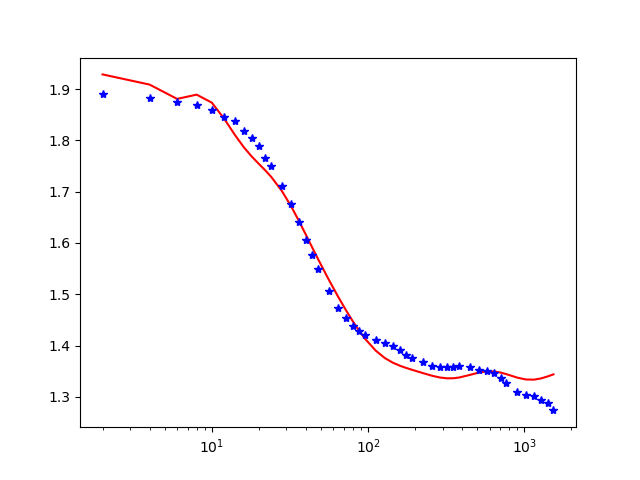

[ 9.48056053e-01  3.99326571e-01  5.60374357e+01  8.41801674e+04
  1.17346522e+00  8.47388899e+00 -5.78570204e-03  7.61010550e-03
  3.64495673e+00  7.52808220e+00 -9.23951324e-01]


In [238]:
def ISF(t,A,a,tt1,tt2,b1,b2,a1,a2,phi,pphi,delta):
    omega = 2*np.pi/np.log(3)
    return 1+A*np.abs((a*np.exp(-(t/tt1)**b1)+(1-a)*np.exp(-(t/tt2)**b2))*(1+a1*np.exp(1j*(omega*np.log(t)+phi))+a2*np.exp(1j*((omega+delta)*np.log(t)+pphi))))**2

lower_bounds = [0,0,0]
upper_bounds = [np.inf,np.inf,np.inf]

popt,pcov = curve_fit(ISF,delays[0],g2s[9,:],sigma=g2s_err[0,:],absolute_sigma=True,p0=[1,0.92,33,6500,2.0,1,-0.5,0.7,0.4,1.2,0.2])#,bounds=(lower_bounds, upper_bounds))

fig,ax=plt.subplots()

ax.semilogx(delays[0],ISF(delays[0],*popt),'r')
ax.semilogx(delays[0],g2s[9,:],'b*')

print(popt)

<IPython.core.display.Javascript object>


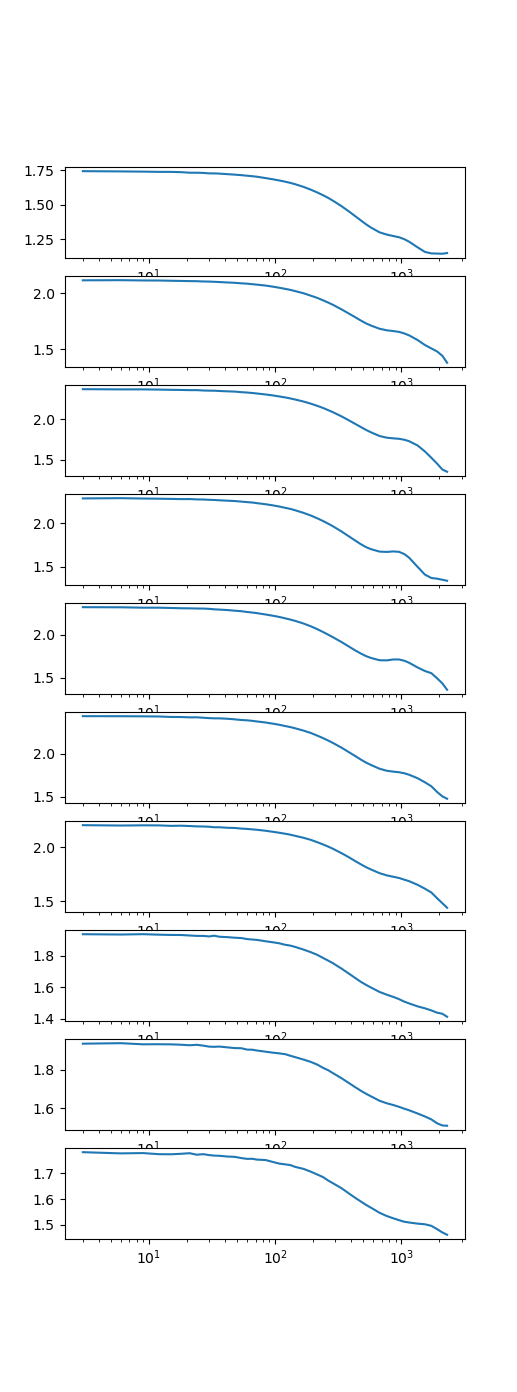

In [32]:
fig,ax = plt.subplots(g2s.shape[0],1)

for i,g2 in enumerate(g2s):
    ax[i].semilogx(delays[0],g2)
#ax.semilogx(delays[0],g2s[9,:])

In [198]:
1j*1j

(-1+0j)